# Regula Falsi (False Position) Method
---
## Learning Objectives
1. Derive Regula Falsi iteration formula.
2. Compare with Bisection method theoretically.
3. Analyze convergence behavior.
4. Detect stagnation issues.
5. Implement modified Regula Falsi.


## Theoretical Background

Given $f(a)f(b) < 0$, the Regula Falsi method approximates the root by:

$$
x_n = b - f(b)\frac{(b-a)}{f(b)-f(a)}
$$

It replaces the midpoint (as in Bisection) with the intersection of the secant line.

### Key Property
- Always maintains bracketing.
- Convergence is linear.
- Can suffer from endpoint stagnation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implement General Regula Falsi Function
Include:
1. Bracketing validation
2. Multiple stopping criteria
3. Iteration history recording


In [2]:
def regula_falsi(f, a, b, tol=1e-8, max_iter=100):
    if f(a)*f(b) >= 0:
        raise ValueError('Invalid interval: f(a) and f(b) must have opposite signs.')

    history = []

    for n in range(1, max_iter+1):
        fa = f(a)
        fb = f(b)
        c = b - fb*(b-a)/(fb-fa)
        fc = f(c)

        history.append((n, a, b, c, fc))

        if abs(fc) < tol or abs(b-a) < tol:
            return c, history

        if fa*fc < 0:
            b = c
        else:
            a = c

    return c, history

Solve: $x^3 - x - 2 = 0$ on interval [1,2]

In [4]:
def f1(x):
    return x**3 - x - 2

root1, hist1 = regula_falsi(f1, 1, 2)
root1

1.5213797063123649

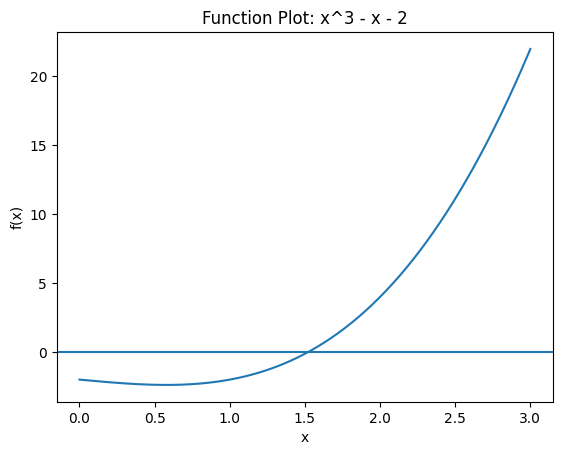

In [5]:
x = np.linspace(0, 3, 400)
y = f1(x)

plt.figure()
plt.plot(x, y)
plt.axhline(0)
plt.title('Function Plot: x^3 - x - 2')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Compute error sequence and observe linear convergence.

In [6]:
exact_root = root1
errors = []

for n, a_val, b_val, c_val, fc_val in hist1:
    errors.append(abs(c_val - exact_root))

errors

[0.18804637297903137,
 0.05869313914818575,
 0.017360702362416047,
 0.005049141552101899,
 0.0014611562890087804,
 0.0004222249404344236,
 0.00012195718607932449,
 3.522208084194567e-05,
 1.0171774763145791e-05,
 2.937225183075043e-06,
 8.479084709911433e-07,
 2.4452220781512324e-07,
 7.026687209865656e-08,
 1.994270282246191e-08,
 5.409306780279621e-09,
 1.2121268433418209e-09,
 0.0]

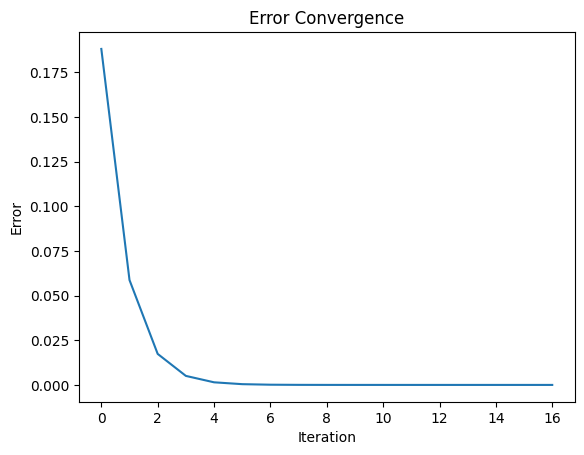

In [7]:
plt.figure()
plt.plot(errors)
plt.title('Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.show()

Try solving:
$
e^{-x} - x = 0
$

In [9]:
def f_stag(x):
    return np.exp(-x) - x

root_stag, hist_stag = regula_falsi(f_stag, 0, 1)
root_stag

0.567143291468663

Implement Illinois or Modified Regula Falsi method to overcome stagnation.


In [10]:
def modified_regula_falsi(f, a, b, tol=1e-8, max_iter=100):
    if f(a)*f(b) >= 0:
        raise ValueError('Invalid interval.')

    fa = f(a)
    fb = f(b)

    for n in range(max_iter):
        c = b - fb*(b-a)/(fb-fa)
        fc = f(c)

        if abs(fc) < tol:
            return c

        if fa*fc < 0:
            b = c
            fb = fc/2
        else:
            a = c
            fa = fc/2

    return c